# Regresión Lineal Simple: Número de Reclamos vs Pago Total de Seguros

**Dataset:** `slr06.xls` — datos de una compañía de seguros de autos en Suecia.

- **X** = número de reclamos (claims) registrados.
- **Y** = pago total de todos los reclamos, en miles de coronas suecas.

**Objetivo:** ajustar un modelo de regresión lineal simple $Y = \beta_0 + \beta_1 X + \varepsilon$
y comprobar, con gráficos y pruebas estadísticas, que se cumplen los supuestos
necesarios para que el modelo sea válido:

1. Linealidad
2. Independencia de los errores
3. Homocedasticidad (varianza constante de los errores)
4. Normalidad de los errores
5. Ausencia de observaciones influyentes/atípicas graves


In [1]:
# ============================================================
# LIBRERÍAS NECESARIAS
# ============================================================
import numpy as np                        # Operaciones numéricas
import pandas as pd                       # Manejo de datos tabulares
import matplotlib.pyplot as plt           # Gráficos base
import seaborn as sns                     # Gráficos estadísticos
import statsmodels.api as sm              # Herramientas de regresión y diagnóstico
import statsmodels.formula.api as smf     # Interfaz tipo fórmula (más legible: 'Y ~ X')
from statsmodels.stats.stattools import durbin_watson       # Prueba de independencia
from statsmodels.stats.diagnostic import het_breuschpagan   # Prueba de homocedasticidad
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats                    # Pruebas de normalidad (Shapiro-Wilk)

# Configuración visual para que los gráficos se vean consistentes
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

# Nivel de significancia que usaremos en todas las pruebas de hipótesis
ALPHA = 0.05


## 1. Carga y exploración inicial de los datos

In [2]:
# El archivo .xls original es un formato binario antiguo (BIFF) que pandas
# no siempre detecta automáticamente, por lo que forzamos el motor 'xlrd'.
df = pd.read_excel('slr06.xls', engine='xlrd')

# Renombramos las columnas con nombres descriptivos en español
df = df.rename(columns={'X': 'num_reclamos', 'Y': 'pago_total_miles'})

X_col = 'num_reclamos'       # Variable independiente (predictora)
Y_col = 'pago_total_miles'   # Variable dependiente (respuesta)

print(f'Número de observaciones (n): {len(df)}')
df.head(10)


*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'
Número de observaciones (n): 63


,num_reclamos,pago_total_miles
0,108,392.5
1,19,46.2
2,13,15.7
3,124,422.2
4,40,119.4
5,57,170.9
6,23,56.9
7,14,77.5
8,45,214.0
9,10,65.3


In [3]:
# Estadística descriptiva de ambas variables: nos da una primera idea
# de escalas, dispersión y posibles valores extremos.
df.describe().T


,count,mean,std,min,25%,50%,75%,max
num_reclamos,63.0,22.904762,23.351946,0.0,7.50,14.0,29.0,124.0
pago_total_miles,63.0,98.187302,87.327553,0.0,38.85,73.4,140.0,422.2


## 2. Supuesto 1 — Linealidad (análisis exploratorio)

Antes de ajustar cualquier modelo, se debe verificar visualmente que la relación
entre X e Y sea aproximadamente lineal. Si el patrón fuera curvo, un modelo
lineal simple no sería adecuado.

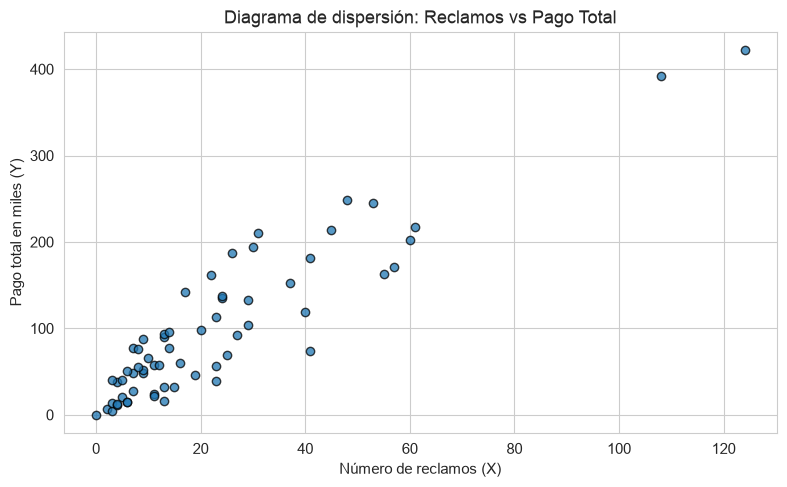

In [4]:
fig, ax = plt.subplots()
ax.scatter(df[X_col], df[Y_col], alpha=0.75, edgecolor='k')
ax.set_xlabel('Número de reclamos (X)')
ax.set_ylabel('Pago total en miles (Y)')
ax.set_title('Diagrama de dispersión: Reclamos vs Pago Total')
plt.tight_layout()
plt.show()


In [5]:
# Coeficiente de correlación de Pearson: mide la fuerza y dirección
# de la relación LINEAL entre X e Y (va de -1 a 1).
correlacion = df[X_col].corr(df[Y_col])
print(f'Coeficiente de correlación de Pearson (r): {correlacion:.4f}')


Coeficiente de correlación de Pearson (r): 0.9129


**Lectura:** el diagrama de dispersión muestra una tendencia creciente y
razonablemente lineal entre el número de reclamos y el pago total, y el
coeficiente de correlación confirma una relación lineal fuerte. Esto respalda
el uso de un modelo de regresión lineal simple.

## 3. Ajuste del modelo de regresión lineal simple

In [6]:
# Ajustamos el modelo Y = b0 + b1*X por mínimos cuadrados ordinarios (OLS).
# La sintaxis tipo fórmula 'pago_total_miles ~ num_reclamos' es equivalente
# a especificar Y en función de X.
modelo = smf.ols(f'{Y_col} ~ {X_col}', data=df).fit()

# El resumen incluye: coeficientes, errores estándar, estadísticos t, p-values,
# R², R² ajustado, prueba F global, y algunos diagnósticos preliminares.
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:       pago_total_miles   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     305.0
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           2.05e-25
Time:                        23:00:59   Log-Likelihood:                -314.04
No. Observations:                  63   AIC:                             632.1
Df Residuals:                      61   BIC:                             636.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.9945      6.368      3.140   

In [7]:
# Extraemos los valores clave del modelo para interpretarlos de forma dinámica
b0, b1 = modelo.params.iloc[0], modelo.params.iloc[1]
r2 = modelo.rsquared
pval_pendiente = modelo.pvalues[X_col]

print(f'Ecuación estimada:  pago_total_miles = {b0:.3f} + {b1:.3f} * num_reclamos')
print(f'R² = {r2:.4f}  ->  el modelo explica el {r2*100:.1f}% de la variabilidad de Y')
print(f'p-value de la pendiente (b1) = {pval_pendiente:.2e}  ->  '
      f'{"significativa" if pval_pendiente < ALPHA else "NO significativa"} al {int(ALPHA*100)}%')


Ecuación estimada:  pago_total_miles = 19.994 + 3.414 * num_reclamos
R² = 0.8333  ->  el modelo explica el 83.3% de la variabilidad de Y
p-value de la pendiente (b1) = 2.05e-25  ->  significativa al 5%


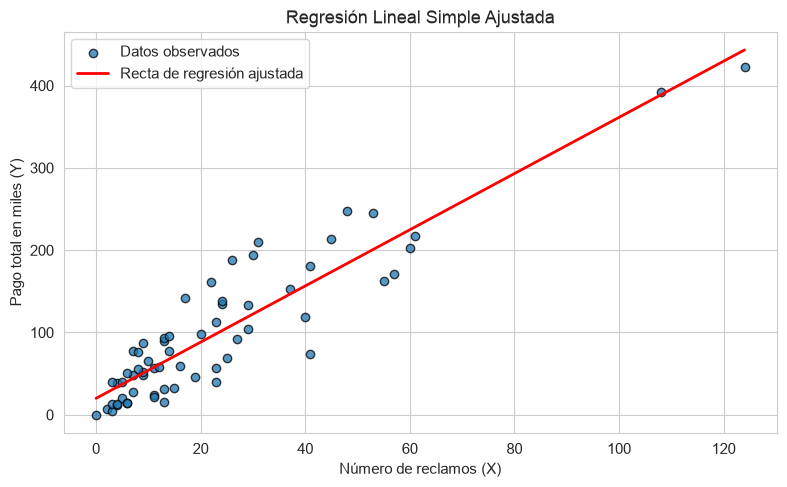

In [8]:
# Visualizamos los datos junto con la recta de regresión ajustada
fig, ax = plt.subplots()
ax.scatter(df[X_col], df[Y_col], alpha=0.75, edgecolor='k', label='Datos observados')

x_vals = np.linspace(df[X_col].min(), df[X_col].max(), 100)
y_vals = b0 + b1 * x_vals
ax.plot(x_vals, y_vals, color='red', linewidth=2, label='Recta de regresión ajustada')

ax.set_xlabel('Número de reclamos (X)')
ax.set_ylabel('Pago total en miles (Y)')
ax.set_title('Regresión Lineal Simple Ajustada')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Verificación de los supuestos del modelo

Para que las inferencias del modelo (intervalos de confianza, p-values) sean
válidas, los **residuos** ($e_i = Y_i - \hat{Y}_i$) deben cumplir varias
condiciones. Calculamos primero los residuos y valores ajustados.

In [9]:
# Valores ajustados (predicciones del modelo) y residuos
df['valor_ajustado'] = modelo.fittedvalues
df['residuo'] = modelo.resid

# Residuos estandarizados (estudentizados internos): útiles para detectar
# atípicos, ya que están en unidades de desviación estándar.
influencia = OLSInfluence(modelo)
df['residuo_estandarizado'] = influencia.resid_studentized_internal

df[[X_col, Y_col, 'valor_ajustado', 'residuo', 'residuo_estandarizado']].head(10)


,num_reclamos,pago_total_miles,valor_ajustado,residuo,residuo_estandarizado
0,108,392.5,388.687430,3.812570,0.120892
1,19,46.2,84.857133,-38.657133,-1.084462
2,13,15.7,64.374192,-48.674192,-1.367178
3,124,422.2,443.308607,-21.108607,-0.711263
4,40,119.4,156.547428,-37.147428,-1.046477
5,57,170.9,214.582429,-43.682429,-1.247138
6,23,56.9,98.512428,-41.612428,-1.167101
7,14,77.5,67.788016,9.711984,0.272716
8,45,214.0,173.616546,40.383454,1.141034
9,10,65.3,54.132721,11.167279,0.313995


### 4.1 Linealidad y homocedasticidad — Residuos vs Valores Ajustados

Si el modelo lineal es adecuado y la varianza de los errores es constante,
los residuos deben distribuirse **aleatoriamente alrededor de cero**, sin
ningún patrón curvo (linealidad) ni un "embudo" que se abra o cierre
(homocedasticidad).

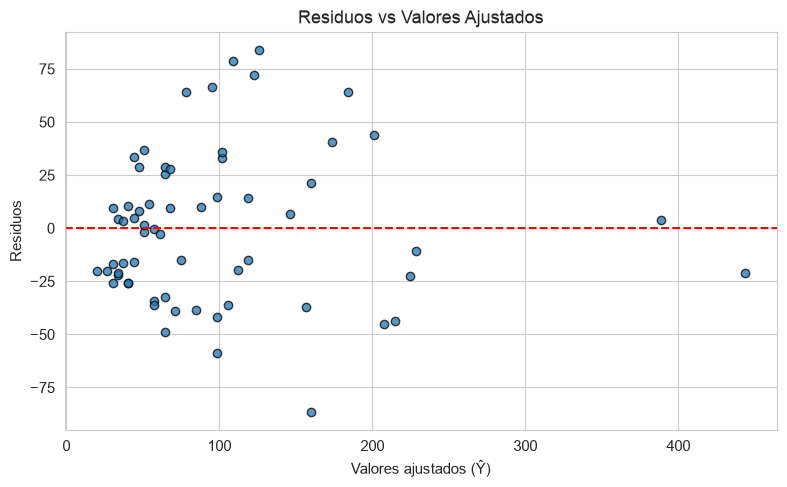

In [10]:
fig, ax = plt.subplots()
ax.scatter(df['valor_ajustado'], df['residuo'], alpha=0.75, edgecolor='k')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Valores ajustados (Ŷ)')
ax.set_ylabel('Residuos')
ax.set_title('Residuos vs Valores Ajustados')
plt.tight_layout()
plt.show()


**Cómo leer este gráfico:**
- Un patrón curvo indicaría que la relación real no es lineal.
- Un "embudo" (la dispersión de los residuos crece o decrece con Ŷ) indicaría
  heterocedasticidad, lo cual se confirma formalmente en la sección 4.3.

### 4.2 Independencia de los errores — Estadístico de Durbin-Watson

Este supuesto es más relevante en datos de series de tiempo, pero se reporta
como buena práctica. El estadístico de Durbin-Watson va de 0 a 4:
- **≈ 2** → no hay autocorrelación.
- **cercano a 0** → autocorrelación positiva.
- **cercano a 4** → autocorrelación negativa.

In [11]:
dw = durbin_watson(modelo.resid)
print(f'Estadístico de Durbin-Watson: {dw:.4f}')

if 1.5 < dw < 2.5:
    print('Conclusión: valor cercano a 2 -> no hay evidencia de autocorrelación relevante.')
else:
    print('Conclusión: el valor se aleja de 2 -> podría existir autocorrelación en los residuos.')


Estadístico de Durbin-Watson: 1.1993
Conclusión: el valor se aleja de 2 -> podría existir autocorrelación en los residuos.


### 4.3 Homocedasticidad — Gráfico de Escala-Ubicación y Prueba de Breusch-Pagan

Complementamos el análisis visual con una prueba formal de hipótesis:

- $H_0$: la varianza de los residuos es constante (homocedasticidad).
- $H_1$: la varianza de los residuos NO es constante (heterocedasticidad).

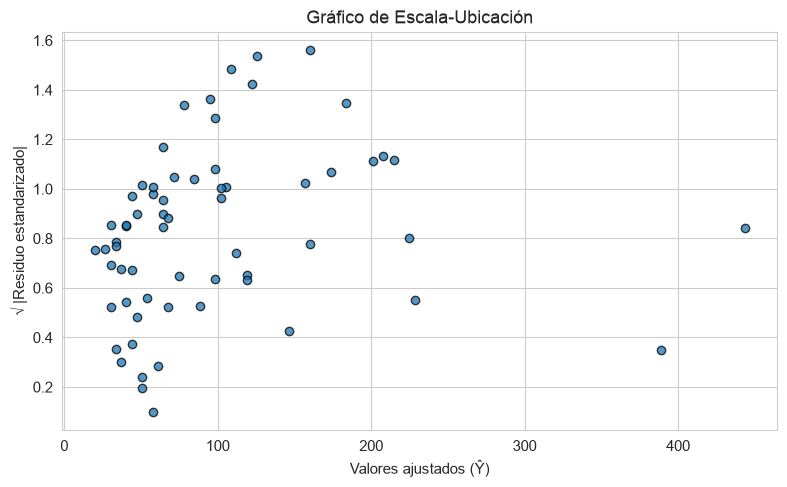

In [12]:
# Gráfico de escala-ubicación: raíz cuadrada del residuo estandarizado
# absoluto vs valores ajustados. Una tendencia creciente sugiere heterocedasticidad.
fig, ax = plt.subplots()
ax.scatter(df['valor_ajustado'], np.sqrt(np.abs(df['residuo_estandarizado'])),
           alpha=0.75, edgecolor='k')
ax.set_xlabel('Valores ajustados (Ŷ)')
ax.set_ylabel('√ |Residuo estandarizado|')
ax.set_title('Gráfico de Escala-Ubicación')
plt.tight_layout()
plt.show()


In [13]:
# Prueba de Breusch-Pagan
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(modelo.resid, modelo.model.exog)

print(f'Estadístico LM de Breusch-Pagan: {bp_stat:.4f}')
print(f'p-value: {bp_pvalue:.4f}')

if bp_pvalue < ALPHA:
    print(f'\nConclusión: p-value < {ALPHA} -> se rechaza H0 -> '
          'hay evidencia de HETEROCEDASTICIDAD.')
else:
    print(f'\nConclusión: p-value >= {ALPHA} -> no se rechaza H0 -> '
          'no hay evidencia contra la homocedasticidad.')


Estadístico LM de Breusch-Pagan: 1.7109
p-value: 0.1909

Conclusión: p-value >= 0.05 -> no se rechaza H0 -> no hay evidencia contra la homocedasticidad.


### 4.4 Normalidad de los residuos — Histograma, Q-Q Plot y Shapiro-Wilk

- $H_0$: los residuos provienen de una distribución normal.
- $H_1$: los residuos NO provienen de una distribución normal.

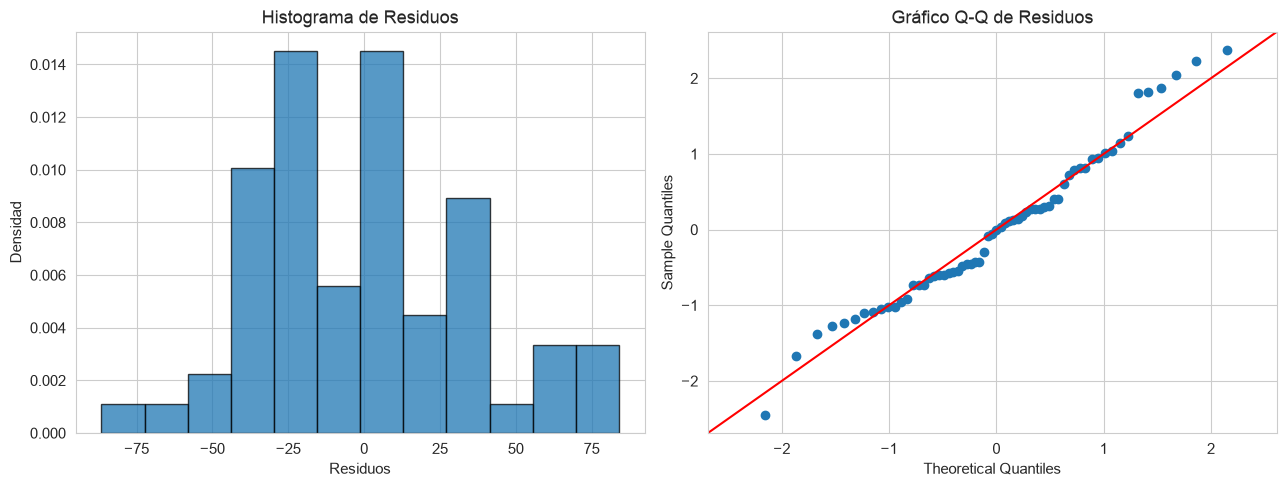

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de residuos con curva de densidad
axes[0].hist(df['residuo'], bins=12, edgecolor='k', alpha=0.75, density=True)
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Histograma de Residuos')

# Gráfico Q-Q: compara los cuantiles de los residuos contra una normal teórica.
# Si los puntos siguen la línea de 45°, los residuos son aproximadamente normales.
sm.qqplot(df['residuo'], line='45', fit=True, ax=axes[1])
axes[1].set_title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()


In [15]:
# Prueba de Shapiro-Wilk para normalidad
shapiro_stat, shapiro_pvalue = stats.shapiro(df['residuo'])
print(f'Estadístico de Shapiro-Wilk: {shapiro_stat:.4f}')
print(f'p-value: {shapiro_pvalue:.4f}')

if shapiro_pvalue < ALPHA:
    print(f'\nConclusión: p-value < {ALPHA} -> se rechaza H0 -> '
          'los residuos NO siguen una distribución normal.')
else:
    print(f'\nConclusión: p-value >= {ALPHA} -> no se rechaza H0 -> '
          'no hay evidencia contra la normalidad de los residuos.')


Estadístico de Shapiro-Wilk: 0.9750
p-value: 0.2262

Conclusión: p-value >= 0.05 -> no se rechaza H0 -> no hay evidencia contra la normalidad de los residuos.


### 4.5 Observaciones influyentes y atípicas — Distancia de Cook y Leverage

Una observación **influyente** puede distorsionar de forma desproporcionada
los coeficientes estimados. Usamos la **distancia de Cook** (regla práctica:
valores mayores a $4/n$ merecen revisión) y el gráfico de influencia
(leverage vs residuos estudentizados).

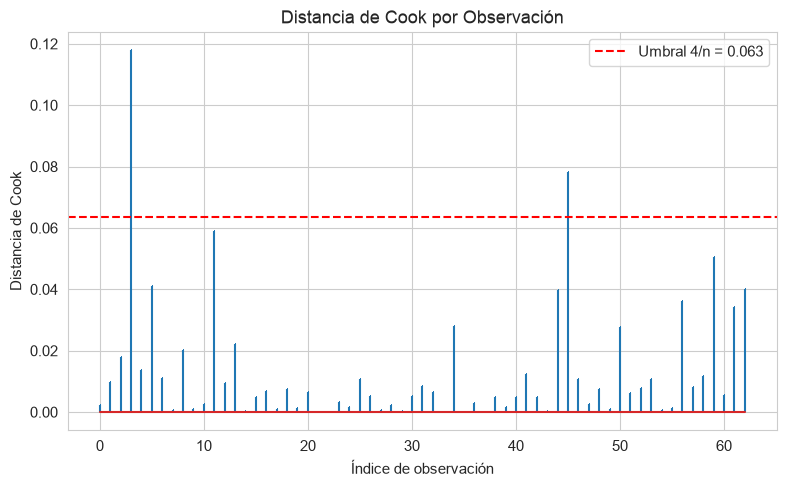

Número de observaciones potencialmente influyentes: 2
Índices: [3, 45]


In [16]:
cooks_d = influencia.cooks_distance[0]
umbral_cook = 4 / len(df)

fig, ax = plt.subplots()
markerline, stemlines, baseline = ax.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(umbral_cook, color='red', linestyle='--', label=f'Umbral 4/n = {umbral_cook:.3f}')
ax.set_xlabel('Índice de observación')
ax.set_ylabel('Distancia de Cook')
ax.set_title('Distancia de Cook por Observación')
ax.legend()
plt.tight_layout()
plt.show()

indices_influyentes = np.where(cooks_d > umbral_cook)[0]
print(f'Número de observaciones potencialmente influyentes: {len(indices_influyentes)}')
print(f'Índices: {indices_influyentes.tolist()}')


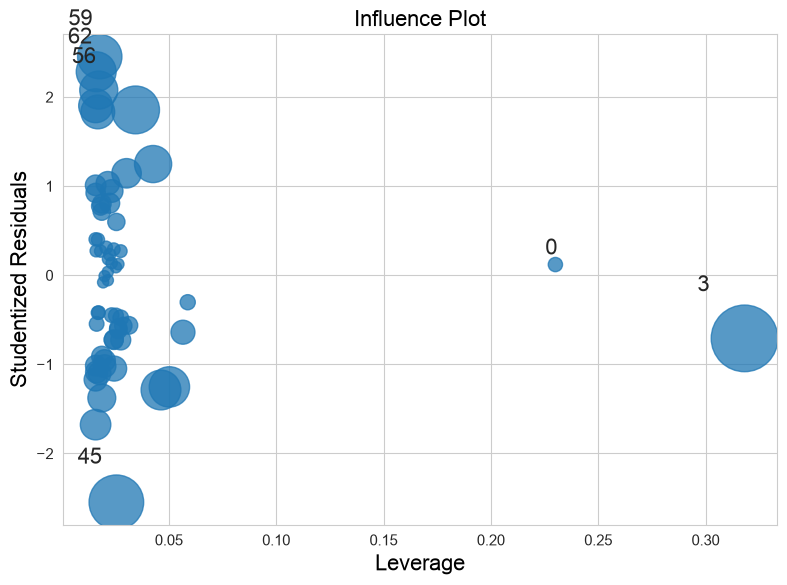

In [17]:
# Gráfico de influencia combinado: leverage (apalancamiento) vs residuos
# estudentizados, con el tamaño de punto proporcional a la distancia de Cook.
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.influence_plot(modelo, ax=ax, criterion='cooks')
plt.tight_layout()
plt.show()


## 5. Resumen de la verificación de supuestos

In [18]:
resumen_supuestos = pd.DataFrame({
    'Supuesto': [
        'Linealidad',
        'Independencia (Durbin-Watson)',
        'Homocedasticidad (Breusch-Pagan)',
        'Normalidad (Shapiro-Wilk)',
        'Sin observaciones muy influyentes',
    ],
    'Estadístico / criterio': [
        'Inspección visual (dispersión y residuos vs ajustados)',
        f'DW = {dw:.3f} (referencia: ≈ 2)',
        f'p-value = {bp_pvalue:.4f} (H0: varianza constante)',
        f'p-value = {shapiro_pvalue:.4f} (H0: normalidad)',
        f'{len(indices_influyentes)} observación(es) con Cook > 4/n',
    ],
    '¿Se cumple?': [
        'Sí (relación aproximadamente lineal)',
        'Sí' if 1.5 < dw < 2.5 else 'Revisar',
        'Sí' if bp_pvalue >= ALPHA else 'No (heterocedasticidad)',
        'Sí' if shapiro_pvalue >= ALPHA else 'No (no normal)',
        'Sí' if len(indices_influyentes) == 0 else 'Revisar observaciones señaladas',
    ],
})
resumen_supuestos


,Supuesto,Estadístico / criterio,¿Se cumple?
0,Linealidad,Inspección visual (dispersión y residuos vs aj...,Sí (relación aproximadamente lineal)
1,Independencia (Durbin-Watson),DW = 1.199 (referencia: ≈ 2),Revisar
2,Homocedasticidad (Breusch-Pagan),p-value = 0.1909 (H0: varianza constante),Sí
3,Normalidad (Shapiro-Wilk),p-value = 0.2262 (H0: normalidad),Sí
4,Sin observaciones muy influyentes,2 observación(es) con Cook > 4/n,Revisar observaciones señaladas


## 6. Conclusiones

- Existe una relación **lineal fuerte y positiva** entre el número de reclamos
  y el pago total: a mayor número de reclamos, mayor el pago total esperado.
- El modelo ajustado explica una proporción importante de la variabilidad de
  Y (ver R² en la sección 3), y la pendiente es estadísticamente significativa.
- La tabla de la sección 5 resume si cada supuesto clásico de la regresión
  lineal (linealidad, independencia, homocedasticidad, normalidad, ausencia
  de observaciones influyentes) se cumple para este conjunto de datos.
- Si alguno de los supuestos no se cumple (por ejemplo, heterocedasticidad),
  se podría considerar: transformar la variable Y (p. ej. logaritmo o raíz
  cuadrada), usar errores estándar robustos, o revisar las observaciones
  influyentes identificadas antes de confiar plenamente en las inferencias
  del modelo.

## 7. Entrenamiento con scikit-learn y predicciones

Además del modelo estadístico ajustado con `statsmodels` (útil para inferencia:
p-values, intervalos de confianza, diagnósticos), entrenamos el mismo modelo
de regresión lineal simple con **scikit-learn**, el estándar para flujos de
machine learning (train/test split, métricas de evaluación, predicción sobre
datos nuevos).

In [19]:
# ============================================================
# LIBRERÍAS DE SCIKIT-LEARN
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### 7.1 División en entrenamiento y prueba

Separamos los datos en un conjunto de **entrenamiento** (80%) y uno de
**prueba** (20%). El modelo se ajusta solo con los datos de entrenamiento y
se evalúa con los de prueba, que el modelo no vio durante el ajuste. Esto da
una estimación más realista de qué tan bien generaliza el modelo a datos
nuevos.

In [20]:
# scikit-learn espera X como una matriz 2D (n_muestras, n_features),
# por eso usamos doble corchete [[X_col]] en vez de [X_col].
X = df[[X_col]]
y = df[Y_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Observaciones de entrenamiento: {len(X_train)}')
print(f'Observaciones de prueba:        {len(X_test)}')


Observaciones de entrenamiento: 50
Observaciones de prueba:        13


### 7.2 Entrenamiento del modelo

In [21]:
# Creamos y entrenamos el modelo de regresión lineal con los datos de entrenamiento
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_train, y_train)

print(f'Intercepto (b0): {modelo_sklearn.intercept_:.4f}')
print(f'Pendiente  (b1): {modelo_sklearn.coef_[0]:.4f}')
print(f'Ecuación: pago_total_miles = {modelo_sklearn.intercept_:.3f} '
      f'+ {modelo_sklearn.coef_[0]:.3f} * num_reclamos')


Intercepto (b0): 16.7502
Pendiente  (b1): 3.4292
Ecuación: pago_total_miles = 16.750 + 3.429 * num_reclamos


**Nota:** los coeficientes deberían ser muy similares a los obtenidos con
`statsmodels` en la sección 3, ya que ambos ajustan el mismo modelo por
mínimos cuadrados ordinarios; las pequeñas diferencias se deben a que aquí
solo se usa el 80% de los datos (conjunto de entrenamiento).

### 7.3 Predicciones y evaluación sobre el conjunto de prueba

In [22]:
# Generamos las predicciones del modelo sobre los datos de prueba (no vistos en el ajuste)
y_pred = modelo_sklearn.predict(X_test)

# Tabla comparativa: valor real vs valor predicho
resultados_test = pd.DataFrame({
    'num_reclamos': X_test[X_col].values,
    'pago_real': y_test.values,
    'pago_predicho': y_pred,
})
resultados_test['error'] = resultados_test['pago_real'] - resultados_test['pago_predicho']
resultados_test = resultados_test.sort_values('num_reclamos').reset_index(drop=True)
resultados_test


,num_reclamos,pago_real,pago_predicho,error
0,7,77.5,40.754878,36.745122
1,10,65.3,51.042581,14.257419
2,11,23.5,54.471815,-30.971815
3,13,89.9,61.330283,28.569717
4,14,95.5,64.759518,30.740482
5,24,137.9,99.051861,38.848139
6,24,134.9,99.051861,35.848139
7,29,133.3,116.198032,17.101968
8,37,152.8,143.631906,9.168094
9,53,244.6,198.499655,46.100345


In [23]:
# Métricas de evaluación del modelo sobre el conjunto de prueba
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred)

print(f'MAE  (Error Absoluto Medio):      {mae:.3f} miles')
print(f'MSE  (Error Cuadrático Medio):    {mse:.3f}')
print(f'RMSE (Raíz del Error Cuadrático): {rmse:.3f} miles')
print(f'R² en conjunto de prueba:         {r2_test:.4f}')


MAE  (Error Absoluto Medio):      26.415 miles
MSE  (Error Cuadrático Medio):    875.043
RMSE (Raíz del Error Cuadrático): 29.581 miles
R² en conjunto de prueba:         0.8951


**Cómo interpretar:**
- **MAE**: en promedio, la predicción se equivoca en esa cantidad de miles de
  coronas, en valor absoluto.
- **RMSE**: similar al MAE pero penaliza más los errores grandes.
- **R² de prueba**: proporción de la variabilidad de Y en datos NO vistos que
  el modelo logra explicar; un valor cercano al R² de entrenamiento indica
  que el modelo generaliza bien (no hay sobreajuste).

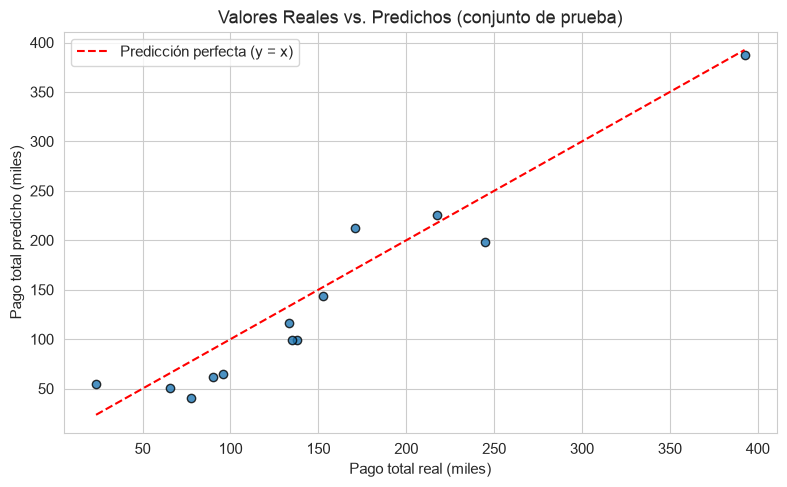

In [24]:
# Gráfico: valores reales vs. predichos en el conjunto de prueba.
# Si el modelo predice perfectamente, todos los puntos caerían sobre la línea diagonal.
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.8, edgecolor='k')

lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--',
        label='Predicción perfecta (y = x)')

ax.set_xlabel('Pago total real (miles)')
ax.set_ylabel('Pago total predicho (miles)')
ax.set_title('Valores Reales vs. Predichos (conjunto de prueba)')
ax.legend()
plt.tight_layout()
plt.show()


### 7.4 Modelo final y predicción sobre valores nuevos de X

Para uso en producción (predecir el pago total dado un número de reclamos
nuevo), reentrenamos el modelo con **todos** los datos disponibles.

In [25]:
# Reentrenamos con el 100% de los datos para maximizar el uso de información
# disponible antes de usar el modelo para predecir casos nuevos.
modelo_final = LinearRegression()
modelo_final.fit(X, y)

print(f'Intercepto (b0): {modelo_final.intercept_:.4f}')
print(f'Pendiente  (b1): {modelo_final.coef_[0]:.4f}')
print(f'R² con todos los datos: {modelo_final.score(X, y):.4f}')


Intercepto (b0): 19.9945
Pendiente  (b1): 3.4138
R² con todos los datos: 0.8333


In [26]:
# Predicción para valores nuevos de X (número de reclamos) que no están en el dataset
nuevos_reclamos = pd.DataFrame({'num_reclamos': [5, 30, 60, 90, 130]})

predicciones_nuevas = modelo_final.predict(nuevos_reclamos)

tabla_predicciones = nuevos_reclamos.copy()
tabla_predicciones['pago_total_predicho_miles'] = predicciones_nuevas.round(2)
tabla_predicciones


,num_reclamos,pago_total_predicho_miles
0,5,37.06
1,30,122.41
2,60,224.82
3,90,327.24
4,130,463.79


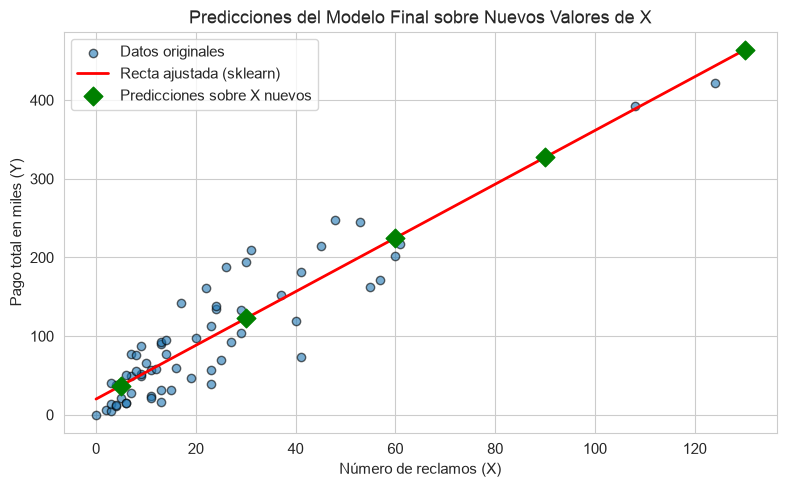

In [27]:
# Visualizamos las predicciones nuevas junto con los datos originales y la recta ajustada
fig, ax = plt.subplots()
ax.scatter(df[X_col], df[Y_col], alpha=0.6, edgecolor='k', label='Datos originales')

x_vals = np.linspace(0, max(df[X_col].max(), nuevos_reclamos['num_reclamos'].max()), 100)
y_vals = modelo_final.intercept_ + modelo_final.coef_[0] * x_vals
ax.plot(x_vals, y_vals, color='red', linewidth=2, label='Recta ajustada (sklearn)')

ax.scatter(nuevos_reclamos['num_reclamos'], predicciones_nuevas, color='green',
           marker='D', s=90, zorder=5, label='Predicciones sobre X nuevos')

ax.set_xlabel('Número de reclamos (X)')
ax.set_ylabel('Pago total en miles (Y)')
ax.set_title('Predicciones del Modelo Final sobre Nuevos Valores de X')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Conclusión final

- El modelo entrenado con `scikit-learn` reproduce, como se esperaba, los
  mismos coeficientes que el modelo de `statsmodels` (sección 3), confirmando
  la consistencia del ajuste.
- La evaluación sobre el conjunto de prueba (datos no usados para entrenar)
  muestra que el modelo generaliza razonablemente bien, con un R² de prueba
  cercano al obtenido en el análisis completo.
- El modelo final (entrenado con el 100% de los datos) permite predecir el
  pago total esperado para cualquier número de reclamos nuevo, como se
  ilustra en la sección 7.4.